In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 1. Примерни данни
# -----------------------------
X = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100]).reshape(-1, 1)
Y = np.array([15, 25, 35, 45, 55, 65, 80, 95, 120, 150])  # Y леко не-линейно и асиметрично

# Функция за оценка на модела
def evaluate_model(model, X, Y_true, logY=False):
    Y_pred = model.predict(X)
    if logY:
        # Ако моделът е обучен върху log(Y), връщаме прогнозите обратно чрез експоненциална функция
        Y_pred = np.exp(Y_pred)
    mse = mean_squared_error(Y_true, Y_pred)
    rmse = root_mean_squared_error(Y_true, Y_pred)
    mae = mean_absolute_error(Y_true, Y_pred)
    r2 = r2_score(Y_true, Y_pred)
    return mse, rmse, mae, r2

# -----------------------------
# 2. Линейна регресия върху оригинални данни
# -----------------------------
model_orig = LinearRegression()
model_orig.fit(X, Y)
mse_orig, rmse_orig, mae_orig, r2_orig = evaluate_model(model_orig, X, Y)

# -----------------------------
# 3. Линейна регресия след log(X)
# -----------------------------
X_log = np.log(X)
model_logX = LinearRegression()
model_logX.fit(X_log, Y)
mse_logX, rmse_logX, mae_logX, r2_logX = evaluate_model(model_logX, X_log, Y)

# -----------------------------
# 4. Линейна регресия след log(Y)
# -----------------------------
Y_log = np.log(Y)
model_logY = LinearRegression()
model_logY.fit(X, Y_log)
mse_logY, rmse_logY, mae_logY, r2_logY = evaluate_model(model_logY, X, Y, logY=True)

# -----------------------------
# 5. Линейна регресия след log(X) и log(Y) (log-log регресия)
# -----------------------------
model_logXY = LinearRegression()
model_logXY.fit(X_log, Y_log)
mse_logXY,rmse_logXY, mae_logXY, r2_logXY = evaluate_model(model_logXY, X_log, Y, logY=True)

# -----------------------------
# 6. Сравнение на резултатите
# -----------------------------
results = pd.DataFrame({
    "Модел": ["Оригинални X,Y", "log(X)", "log(Y)", "log(X) и log(Y)"],
    "MSE": [mse_orig, mse_logX, mse_logY, mse_logXY],
    "RMSE": [rmse_orig, rmse_logX, rmse_logY, rmse_logXY],
    "MAE": [mae_orig, mae_logX, mae_logY, mae_logXY],
    "R2": [r2_orig, r2_logX, r2_logY, r2_logXY]
})

print(results)


             Модел         MSE       RMSE        MAE        R2
0   Оригинални X,Y   79.181818   8.898417   7.454545  0.952734
1           log(X)  374.873788  19.361658  16.226836  0.776228
2           log(Y)   26.262321   5.124678   4.420088  0.984323
3  log(X) и log(Y)  121.704412  11.031972   7.214507  0.927351


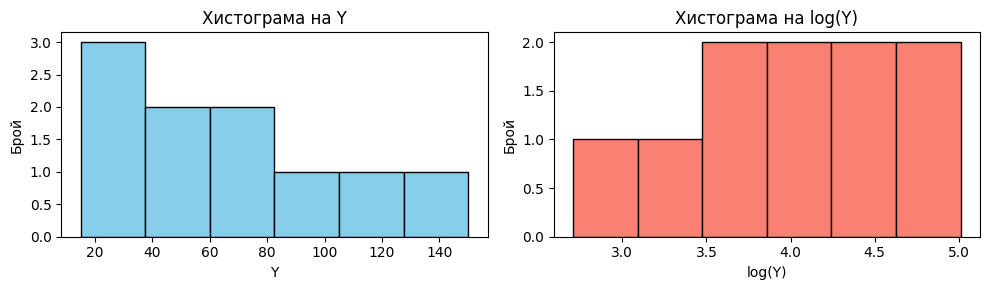

In [5]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. Хистограма на Y и log(Y)
# -----------------------------
plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.hist(Y, bins=6, color='skyblue', edgecolor='black')
plt.title('Хистограма на Y')
plt.xlabel('Y')
plt.ylabel('Брой')

plt.subplot(1,2,2)
plt.hist(Y_log, bins=6, color='salmon', edgecolor='black')
plt.title('Хистограма на log(Y)')
plt.xlabel('log(Y)')
plt.ylabel('Брой')

plt.tight_layout()
plt.show()

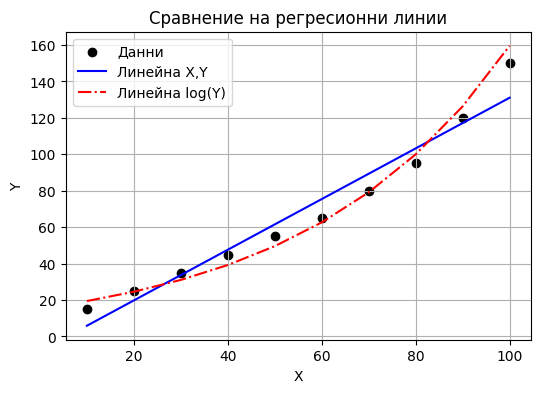

In [6]:
# -----------------------------
# 2. Регресионни линии
# -----------------------------
# -----------------------------
# Модели
# -----------------------------
models = {}
models['orig'] = LinearRegression().fit(X, Y)
models['logX'] = LinearRegression().fit(X_log, Y)
models['logY'] = LinearRegression().fit(X, Y_log)
models['logXY'] = LinearRegression().fit(X_log, Y_log)

plt.figure(figsize=(6,4))

# Оригинални X,Y
plt.scatter(X, Y, color='black', label='Данни')
plt.plot(X, models['orig'].predict(X), color='blue', label='Линейна X,Y')

# log(X)
# plt.plot(X, models['logX'].predict(X_log), color='green', linestyle='--', label='Линейна log(X)')

# log(Y)
Y_log_pred = np.exp(models['logY'].predict(X))  # обратно преобразуване
plt.plot(X, Y_log_pred, color='red', linestyle='-.', label='Линейна log(Y)')

# log(X) и log(Y)
# Y_logXY_pred = np.exp(models['logXY'].predict(X_log))
# plt.plot(X, Y_logXY_pred, color='purple', linestyle=':', label='Линейна log(X) и log(Y)')

plt.title('Сравнение на регресионни линии')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

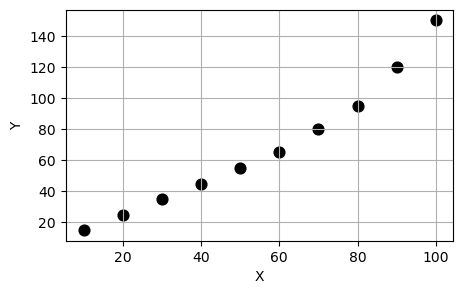

In [27]:
# Графика X срещу Y
plt.figure(figsize=(5,3))
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.scatter(X, Y, color='black', s=60, label='Данни')

In [42]:
!pip install --upgrade scikit-learn.metrics

ERROR: Could not find a version that satisfies the requirement scikit-learn.metrics (from versions: none)
ERROR: No matching distribution found for scikit-learn.metrics


In [12]:
import sklearn
print(sklearn.__version__)

1.2.2


In [2]:
!pip install -U scikit-learn